# KAN From Scratch — Toy Demo: Validating a Kolmogorov-Arnold Additive Model

This notebook is a sanity check, not a clinical experiment. Before KANVAS ever sees real patient data, we need proof that its architecture — an **additive model where every feature gets its own independent, learned nonlinear function** — actually works: that it can recover known functions from data, and that it doesn't cheat by letting features interact.

We'll do this with fully synthetic data where we control the ground truth:

- `feature_1`: a **sinusoidal** effect, `sin(feature_1)`
- `feature_2`: a **U-shaped** effect, `0.5 * (feature_2 - 5)^2` — like a biomarker with a healthy range and danger on both sides
- `feature_3`: a **linear** effect, `0.3 * feature_3`

The true log-odds of the outcome is just the sum of these three contributions. We'll train a `KAAM` model on binary labels sampled from this process, then plot what it *learned* against what we know to be *true*. If the shapes match, the architecture works.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import torch
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from kanvas.model import KAAM
from kanvas.utils import set_seed

set_seed(42)
%matplotlib inline

## Step 1 — Generate synthetic data with a known ground truth

We sample 2000 patients with three independent features, compute each feature's *true* contribution with a different shape on purpose (sinusoidal, U-shaped, linear), sum them into a true log-odds, convert to a true probability with the sigmoid, and finally flip a coin per patient (Bernoulli sampling) to get a binary label. This last step matters: the model never sees `true_probability` — only noisy 0/1 outcomes, exactly like real clinical labels.

In [2]:
N = 2000

feature_1 = np.random.uniform(-3, 3, N)
feature_2 = np.random.uniform(0, 10, N)
feature_3 = np.random.uniform(-5, 5, N)

true_contrib_1 = np.sin(feature_1)
true_contrib_2 = 0.5 * (feature_2 - 5) ** 2
true_contrib_3 = 0.3 * feature_3

true_logit = true_contrib_1 + true_contrib_2 + true_contrib_3
true_probability = 1 / (1 + np.exp(-true_logit))
labels = np.random.binomial(1, true_probability)

X = np.stack([feature_1, feature_2, feature_3], axis=1).astype(np.float32)
y = labels.astype(np.float32)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Positive label rate: {y.mean():.3f}")

X shape: (2000, 3), y shape: (2000,)
Positive label rate: 0.827


## Step 2 — Train/test split, then build the KAAM model

We hold out 20% of the data for testing. `KAAM` needs to know each feature's expected range up front (`feature_ranges`) so it can place each feature's B-spline grid sensibly — we pass in the ranges we generated the data with.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

feature_names = ["feature_1", "feature_2", "feature_3"]
feature_ranges = {"feature_1": (-3, 3), "feature_2": (0, 10), "feature_3": (-5, 5)}

model = KAAM(feature_names, feature_ranges, num_knots=10, spline_order=3)
print(model)

KAAM(
  (edges): ModuleDict(
    (feature_1): BSplineEdge()
    (feature_2): BSplineEdge()
    (feature_3): BSplineEdge()
  )
)

## Step 3 — Train with binary cross-entropy and Adam

Nothing exotic here: standard binary cross-entropy loss on the model's sigmoid output, optimized with Adam. We print the loss every 50 epochs to confirm it's actually converging, not just running.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.BCELoss()

num_epochs = 1000
losses = []

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = loss_fn(preds, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d}/{num_epochs}  train BCE loss: {loss.item():.4f}")

Epoch   50/1000  train BCE loss: 0.3791


Epoch  100/1000  train BCE loss: 0.3300


Epoch  150/1000  train BCE loss: 0.3044


Epoch  200/1000  train BCE loss: 0.2898


Epoch  250/1000  train BCE loss: 0.2808


...

Epoch  800/1000  train BCE loss: 0.2586


Epoch  850/1000  train BCE loss: 0.2581


Epoch  900/1000  train BCE loss: 0.2577


Epoch  950/1000  train BCE loss: 0.2574


Epoch 1000/1000  train BCE loss: 0.2571


Let's also plot the loss curve directly, to visually confirm convergence rather than just eyeballing the printed numbers.

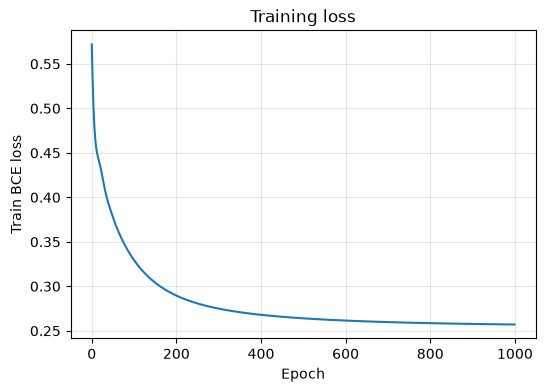

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Train BCE loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

## Step 4 — The critical validation: do the learned curves match the true functions?

This is the whole point of the notebook. `model.plot_all_curves()` plots each feature's *learned* `phi_i(x)` — the function KAAM actually discovered from data. We overlay the *true* functions we used to generate the data (scaled/shifted only by an additive constant, since the model is free to move contribution mass into its bias term) to check the shapes visually:

- `feature_1`'s learned curve should look **sinusoidal**
- `feature_2`'s learned curve should look **U-shaped**
- `feature_3`'s learned curve should look **linear**

If any of these don't match, that's a real bug in the architecture or training — not something to explain away — and it needs to be fixed before real clinical data ever touches this model.

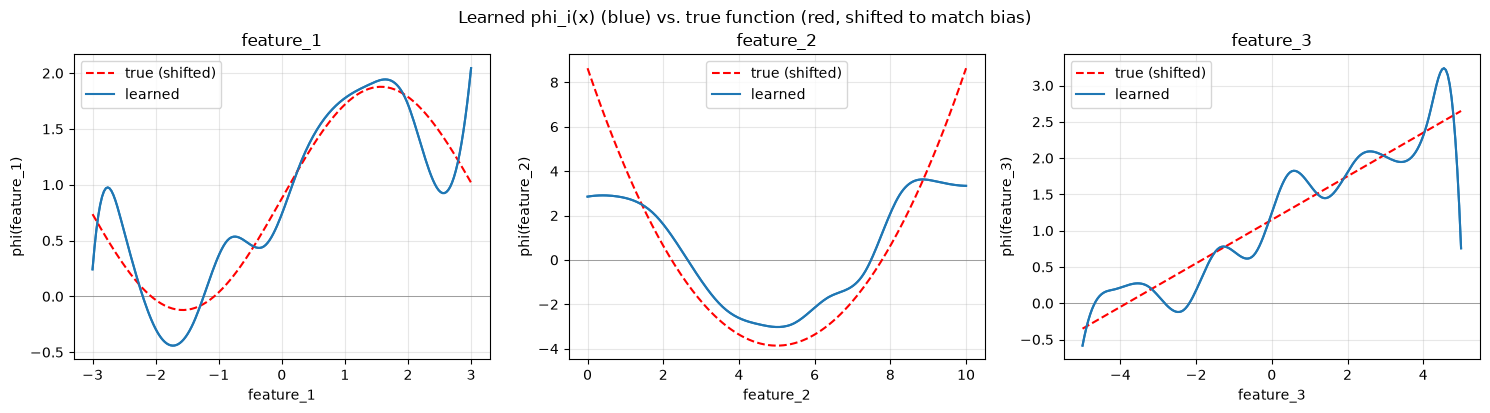

In [6]:
true_funcs = {
    "feature_1": np.sin,
    "feature_2": lambda x: 0.5 * (x - 5) ** 2,
    "feature_3": lambda x: 0.3 * x,
}

fig = model.plot_all_curves()

for ax, name in zip(fig.axes, feature_names):
    x_vals, y_vals = model.edges[name].get_curve()
    true_y = true_funcs[name](x_vals)
    # The model is free to absorb any constant offset into its bias term,
    # so align the true curve to the learned curve's mean before comparing shapes.
    shift = np.mean(y_vals) - np.mean(true_y)
    ax.plot(x_vals, true_y + shift, "--", color="red", label="true (shifted)")
    ax.plot(x_vals, y_vals, color="tab:blue", label="learned")
    ax.legend()

fig.suptitle("Learned phi_i(x) (blue) vs. true function (red, shifted to match bias)", y=1.02)
plt.show()

## Step 5 — Final train/test accuracy and AUC

Beyond the qualitative curve check above, we also confirm the model achieves good quantitative performance on held-out data — accuracy at a 0.5 threshold, and ROC-AUC (which doesn't depend on the threshold choice).

In [7]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_t).numpy()
    test_preds = model(X_test_t).numpy()

train_acc = accuracy_score(y_train, train_preds > 0.5)
test_acc = accuracy_score(y_test, test_preds > 0.5)
train_auc = roc_auc_score(y_train, train_preds)
test_auc = roc_auc_score(y_test, test_preds)

print(f"Train accuracy: {train_acc:.4f}   Train AUC: {train_auc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}   Test  AUC: {test_auc:.4f}")

Train accuracy: 0.8781   Train AUC: 0.9216
Test  accuracy: 0.8775   Test  AUC: 0.9137


## Step 6 — A preview of the interpretability payoff: `explain()`

This is the reason the architecture is built this way. For any single patient, `model.explain(x)` returns each feature's individual contribution *before* the sigmoid — a clean, additive breakdown of exactly how much each feature pushed the prediction up or down. No SHAP approximation, no post-hoc surrogate model: this is what the model actually computed.

In [8]:
sample_patient = X_test_t[0]
contributions = model.explain(sample_patient)

print(f"Patient features: {dict(zip(feature_names, sample_patient.tolist()))}")
print("Per-feature contributions (pre-sigmoid):")
for name, value in contributions.items():
    print(f"  {name:>10s}: {value:+.4f}")

reconstructed_logit = sum(contributions.values()) + model.bias.item()
print(f"\nSum of contributions + bias: {reconstructed_logit:.4f}")
print(f"Sigmoid of that (should match model output): {1 / (1 + np.exp(-reconstructed_logit)):.4f}")
print(f"Model's actual output for this patient:       {model(sample_patient.unsqueeze(0)).item():.4f}")

Patient features: {'feature_1': -2.626249313354492, 'feature_2': 9.28630542755127, 'feature_3': 1.4342894554138184}
Per-feature contributions (pre-sigmoid):
   feature_1: +0.8396
   feature_2: +3.5073
   feature_3: +1.4485

Sum of contributions + bias: 6.6248
Sigmoid of that (should match model output): 0.9987
Model's actual output for this patient:       0.9987


## Conclusion

If the curves in Step 4 visually matched their true shapes and the AUC/accuracy in Step 5 were high, the core claim of KANVAS holds up on data where we know the answer: **an additive model of fully independent per-feature B-spline functions can recover nonlinear, U-shaped, and linear effects simultaneously, with no feature ever seeing another feature's value.** That's the architecture this project is betting on for interpretable clinical risk prediction — the next step, in a separate session, is applying it to real MIMIC-IV data once PhysioNet credentialing is in place.